# <span style="color:#0f766e; font-weight:700;">Analiza Danych (Python) — Lekcja 8: Modele liniowe</span>

1. [Korelacja](#1.-Korelacja)
2. [Prosta regresja liniowa](#2.-Prosta-regresja-liniowa)
3. [Założenia regresji liniowej](#3.-Założenia-regresji-liniowej)
4. [Miary dopasowania modelu](#4.-Miary-dopasowania-modelu)
5. [ANOVA — analiza wariancji](#5.-ANOVA-—-analiza-wariancji)
6. [Testy post-hoc](#6.-Testy-post-hoc)
7. [Wielokrotna regresja liniowa](#7.-Wielokrotna-regresja-liniowa)
8. [Zmienne nominalne w regresji](#8.-Zmienne-nominalne-w-regresji)
9. [Interakcje w modelu liniowym](#9.-Interakcje-w-modelu-liniowym)
10. [Importy i środowisko](#10.-Importy-i-środowisko)
11. [Przykłady](#11.-Przykłady)
12. [Zadania obowiązkowe](#12.-Zadania-obowiązkowe)
13. [Zadania dodatkowe](#13.-Zadania-dodatkowe)
14. [Najczęstsze błędy](#14.-Najczęstsze-błędy)


# <span style="color:#0f766e; font-weight:700;">1. Korelacja</span>

## Co mierzy korelacja?

**Korelacja** opisuje siłę i kierunek **liniowej** zależności między dwiema zmiennymi.

## Korelacja Pearsona (r)

$$r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$$

- r ∈ [−1, 1]; r = 1 idealna dodatnia, r = −1 idealna ujemna, r = 0 brak liniowej zależności.

## Interpretacja |r|

| \|r\| | Interpretacja |
|---|---|
| 0.00 – 0.10 | zaniedbywalna |
| 0.10 – 0.30 | słaba |
| 0.30 – 0.50 | umiarkowana |
| 0.50 – 0.70 | silna |
| 0.70 – 1.00 | bardzo silna |

## Test istotności

H₀: ρ = 0; statystyka t = r√(n−2)/√(1−r²) ~ t(n−2).
W scipy: `stats.pearsonr(x, y)` zwraca (r, p-value).

## Korelacja Spearmana (ρ)

Działa na **rangach** — odporna na wartości odstające, wykrywa **monotoniczne** zależności.
`stats.spearmanr(x, y)`

## Ważne ograniczenia

- **Korelacja ≠ przyczynowość.**
- Pearsona wykrywa tylko zależności **liniowe** — r = 0 nie wyklucza silnej zależności krzywoliniowej.
- Wrażliwa na wartości odstające — kwartet Anscombe'a (Przykład 4).
- Zawsze rysuj wykres rozrzutu przed interpretacją.


# <span style="color:#0f766e; font-weight:700;">2. Prosta regresja liniowa</span>

## Model

$$Y = \beta_0 + \beta_1 X + \varepsilon, \quad \varepsilon \sim N(0, \sigma^2)$$

- **β₀** (intercept): wartość Y gdy X = 0
- **β₁** (slope): zmiana Y przy wzroście X o 1 jednostkę
- **ε**: błąd losowy — część Y niewyjaśniona przez X

## Estymacja MNK (metoda najmniejszych kwadratów)

Minimalizujemy RSS = Σ(yᵢ − ŷᵢ)²:

$$\hat{\beta}_1 = r \cdot \frac{s_y}{s_x}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

## Interpretacja współczynników

| Współczynnik | Znaczenie | Przykład |
|---|---|---|
| β₀ | Y gdy X=0 (często bez sensu) | waga przy wzrost=0 |
| β₁ | zmiana Y na +1 X | +0.5 kg/cm wzrostu |

## scipy vs statsmodels

```python
# scipy — szybko, mało informacji
from scipy import stats
slope, intercept, r, p, se = stats.linregress(x, y)

# statsmodels — pełne podsumowanie, diagnostyka
import statsmodels.formula.api as smf
model = smf.ols('y ~ x', data=df).fit()
print(model.summary())
```


# <span style="color:#0f766e; font-weight:700;">3. Założenia regresji liniowej</span>

## Cztery założenia — akronim LINE

| Litera | Założenie | Jak sprawdzić? |
|---|---|---|
| **L** | **L**iniowość zależności Y od X | wykres rozrzutu Y vs X |
| **I** | **I**ndependence — niezależność reszt | wiedza o projekcie |
| **N** | **N**ormalność reszt | Q-Q plot reszt |
| **E** | **E**qual variance — homoscedastyczność | wykres reszt vs ŷ |

## Diagnostyka graficzna

**Wykres reszt vs dopasowane (ŷ):**
- Dobry model: punkty losowo wokół 0, bez wzorców.
- Heteroscedastyczność: rozproszenie rośnie z ŷ (kształt wachlarza).
- Nieliniowość: widoczny krzywoliniowy wzorzec.

**Q-Q plot:**
- Punkty na linii prostej → reszty normalne → OK.
- Odchylenia na końcach → ciężkie ogony.

## Typowe remedia

| Problem | Rozwiązanie |
|---|---|
| Nieliniowość | log(Y) lub dodanie X² |
| Heteroscedastyczność | log(Y) lub regresja ważona |
| Brak normalności | transformacja; przy dużym n CTG chroni |


# <span style="color:#0f766e; font-weight:700;">4. Miary dopasowania modelu</span>

## Dekompozycja wariancji

$$TSS = ESS + RSS$$

- **TSS** = Σ(yᵢ − ȳ)² — całkowita zmienność Y
- **ESS** = Σ(ŷᵢ − ȳ)² — zmienność wyjaśniona przez model
- **RSS** = Σ(yᵢ − ŷᵢ)² — zmienność niewyjaśniona (reszty)

## R² — współczynnik determinacji

$$R^2 = 1 - \frac{RSS}{TSS} \in [0, 1]$$

R² = 0.72 → model wyjaśnia 72% zmienności Y.  
Dla prostej regresji: R² = r² (kwadrat korelacji Pearsona).

## Adj. R² — uwzględnia liczbę predyktorów

$$\bar{R}^2 = 1 - \frac{RSS/(n-k-1)}{TSS/(n-1)}$$

Stosuj Adj. R² przy porównywaniu modeli z różną liczbą predyktorów.

## Test F całego modelu

H₀: wszystkie β = 0 (model nie wyjaśnia nic).  
F = (ESS/k) / (RSS/(n−k−1)) ~ F(k, n−k−1)

## RMSE — błąd standardowy regresji

$$RMSE = \sqrt{\frac{RSS}{n-2}}$$

Typowy błąd predykcji w jednostkach Y.


# <span style="color:#0f766e; font-weight:700;">5. ANOVA — analiza wariancji</span>

## Idea i hipotezy

**ANOVA** testuje, czy średnie **k ≥ 2 grup** są równe:
- H₀: μ₁ = μ₂ = … = μₖ
- H₁: co najmniej jedna para średnich różni się

## Skąd nazwa "analiza wariancji"?

ANOVA porównuje dwa źródła zmienności:
- **Between Groups (BGS)**: czy grupy różnią się od siebie?
- **Within Groups (WGS)**: naturalne rozproszenie wewnątrz grup

$$F = \frac{BGS/(k-1)}{WGS/(N-k)}$$

## Tabela ANOVA

| Źródło | SS | df | MS = SS/df | F |
|---|---|---|---|---|
| Między grupami | BGS | k−1 | MS_B | MS_B/MS_W |
| Wewnątrz grup | WGS | N−k | MS_W | |
| Łącznie | TSS | N−1 | | |

## ANOVA jako model liniowy

ANOVA = regresja liniowa ze zmiennymi dummy:
Y = β₀ + β₁·G₁ + β₂·G₂ + … + ε

## W Python

```python
from scipy.stats import f_oneway
F, p = f_oneway(grupa1, grupa2, grupa3)

# lub przez statsmodels (z tabelą ANOVA)
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
model = smf.ols('wynik ~ C(grupa)', data=df).fit()
print(anova_lm(model, typ=2))
```


# <span style="color:#0f766e; font-weight:700;">6. Testy post-hoc</span>

## Problem wielokrotnych porównań

Istotna ANOVA mówi że **coś** się różni — ale nie **co**.

Naiwne t-testy dla wszystkich par: przy k=5 grupach mamy C(5,2)=10 par.  
P(co najmniej 1 fałszywy alarm) = 1 − 0.95¹⁰ ≈ **40%** — zbyt duże!

## Poprawka Bonferroniego

α_koryg = α / liczba_testów — konserwatywna, ale prosta.

## Test Tukeya HSD

Kontroluje FWER dla wszystkich par jednocześnie — preferowany przy równych liczebnościach.

```python
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=df['wynik'], groups=df['grupa'], alpha=0.05)
print(tukey)              # tabela par z p-value i decyzją
tukey.plot_simultaneous() # wykres przedziałów ufności
```

## Zasada

Post-hoc **tylko po** istotnym wyniku ANOVA. Nie przeprowadzaj post-hoc bez wcześniejszej ANOVA.


# <span style="color:#0f766e; font-weight:700;">7. Wielokrotna regresja liniowa</span>

## Model

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_k X_k + \varepsilon$$

## Interpretacja — kluczowe

Każdy βⱼ interpretujemy **ceteris paribus** — "przy stałych pozostałych zmiennych".

Przykład: β₁ = 0.3 (wiek → dochód) przy kontrolowaniu wykształcenia oznacza:  
"przy tym samym poziomie wykształcenia, rok starszy pracownik zarabia o 0.3 tys. więcej".

## Miary dopasowania

- R² i **Adj. R²** (używaj Adj. R² przy porównywaniu modeli!)
- Test F — czy model jako całość jest istotny
- t-testy — istotność każdego βⱼ z osobna

## Wielokolinearność

Gdy predyktory są silnie ze sobą skorelowane:
- SE(β) rośnie → t-statystyki maleją → trudno ocenić istotność
- VIF > 5–10 sygnalizuje problem

```python
model = smf.ols('Y ~ X1 + X2 + X3', data=df).fit()
print(model.summary())
```


# <span style="color:#0f766e; font-weight:700;">8. Zmienne nominalne w regresji</span>

## Dummy coding

Zmienną nominalną z k poziomami kodujemy przez **k−1 zmiennych binarnych**.  
Jeden poziom staje się **kategorią referencyjną** (intercept = średnia dla tej kategorii).

## Przykład: 3 gatunki (A, B, C)

| gatunek | D_B | D_C |
|---|---|---|
| A | 0 | 0 |
| B | 1 | 0 |
| C | 0 | 1 |

Model: Y = β₀ + β₁·D_B + β₂·D_C
- β₀ = średnia Y dla A (referencja)
- β₁ = różnica B − A
- β₂ = różnica C − A

## statsmodels robi to automatycznie

```python
# C(zmienna) = traktuj jako kategoryczną (dummy coding)
model = smf.ols('Y ~ C(gatunek)', data=df).fit()
```

Domyślna kategoria referencyjna: pierwsza alfabetycznie.
Zmiana referencji: `C(gatunek, Treatment('B'))`


# <span style="color:#0f766e; font-weight:700;">9. Interakcje w modelu liniowym</span>

## Co to jest interakcja?

Interakcja = wpływ X₁ na Y **zależy od** wartości X₂.

Bez interakcji: linie regresji dla różnych grup są **równoległe**.  
Z interakcją: linie mają **różne nachylenia**.

## Model z interakcją

Y = β₀ + β₁X₁ + β₂X₂ + **β₃(X₁·X₂)** + ε

β₃ > 0: efekt X₁ rośnie wraz z X₂  
β₃ < 0: efekt X₁ maleje wraz z X₂  
β₃ = 0: brak interakcji

## W statsmodels

```python
# * tworzy efekty główne + interakcję
m = smf.ols('Y ~ X * C(grupa)', data=df).fit()
# identyczne z:
m = smf.ols('Y ~ X + C(grupa) + X:C(grupa)', data=df).fit()
```

## Kiedy testować?

- Gdy masz hipotezę o różnym efekcie X między grupami.
- Gdy wykres sugeruje nierownoległe linie.
- Unikaj testowania wszystkich interakcji bez hipotezy (overfitting).


# <span style="color:#0f766e; font-weight:700;">10. Importy i środowisko</span>

Upewnij się, że masz zainstalowane `statsmodels`:
```bash
pip install statsmodels
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.anova import anova_lm

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (8, 4)
print('Biblioteki wczytane pomyślnie.')


Biblioteki wczytane pomyślnie.


# <span style="color:#0f766e; font-weight:700;">11. Przykłady</span>


## <span style="color:#0f766e; font-weight:700;">Przykład 1: Korelacja Pearsona i Spearmana</span>

Badamy zależność między wzrostem a wagą. Obliczamy r, ρ i testujemy istotność.


Pearsona:  r = 0.6216,  p = 7.63e-10
Spearmana: ρ = 0.6090,  p = 2.04e-09
Siła: bardzo silna, kierunek: dodatni, istotna statystycznie.


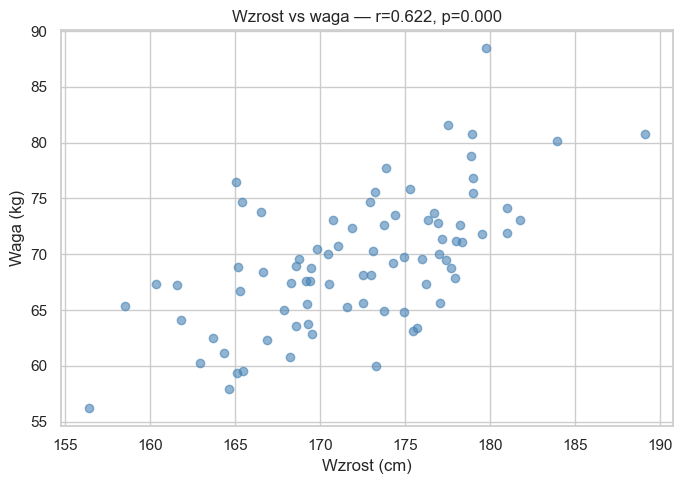

In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
n = 80
wzrost = rng.normal(172, 8, size=n)
waga   = 0.5 * wzrost - 16 + rng.normal(0, 5, size=n)

# Korelacja Pearsona (liniowa) i Spearmana (monotoniczna)
r_p, p_p = stats.pearsonr(wzrost, waga)
r_s, p_s = stats.spearmanr(wzrost, waga)
print(f'Pearsona:  r = {r_p:.4f},  p = {p_p:.2e}')
print(f'Spearmana: ρ = {r_s:.4f},  p = {p_s:.2e}')
print(f'Siła: bardzo silna, kierunek: dodatni, istotna statystycznie.')

plt.figure(figsize=(7, 5))
plt.scatter(wzrost, waga, alpha=0.6, color='steelblue')
plt.xlabel('Wzrost (cm)')
plt.ylabel('Waga (kg)')
plt.title(f'Wzrost vs waga — r={r_p:.3f}, p={p_p:.3f}')
plt.tight_layout()
plt.show()


## <span style="color:#0f766e; font-weight:700;">Przykład 2: Prosta regresja — scipy.stats.linregress</span>

Dopasowujemy linię regresji do danych wzrost/waga. Interpretujemy β₀, β₁ i R².


β₀ = -33.728  (waga gdy wzrost=0 — bez sensu praktycznego)
β₁ = 0.599  (wzrost wagi o 0.60 kg na 1 cm wzrostu)
R² = 0.3863  (model wyjaśnia 38.6% zmienności wagi)
p  = 7.63e-10  (β₁ istotnie różne od 0)


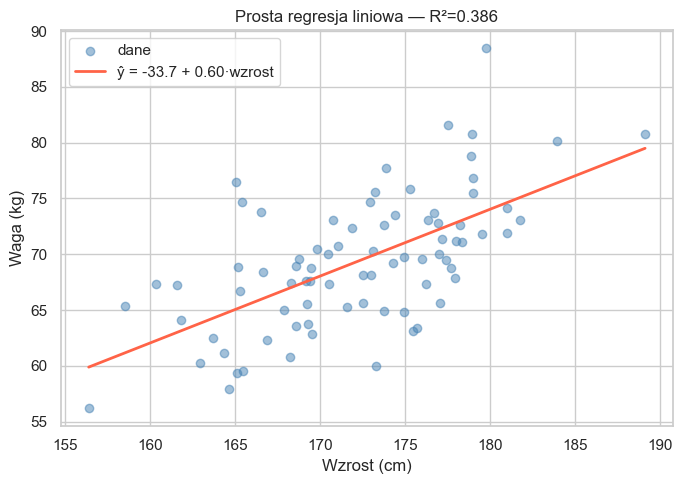

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)
n = 80
wzrost = rng.normal(172, 8, size=n)
waga   = 0.5 * wzrost - 16 + rng.normal(0, 5, size=n)

# Dopasowanie regresji liniowej metodą MNK
wynik = stats.linregress(wzrost, waga)
b0, b1 = wynik.intercept, wynik.slope
r2     = wynik.rvalue**2

print(f'β₀ = {b0:.3f}  (waga gdy wzrost=0 — bez sensu praktycznego)')
print(f'β₁ = {b1:.3f}  (wzrost wagi o {b1:.2f} kg na 1 cm wzrostu)')
print(f'R² = {r2:.4f}  (model wyjaśnia {r2*100:.1f}% zmienności wagi)')
print(f'p  = {wynik.pvalue:.2e}  (β₁ istotnie różne od 0)')

x_line = np.linspace(wzrost.min(), wzrost.max(), 100)
plt.figure(figsize=(7, 5))
plt.scatter(wzrost, waga, alpha=0.5, color='steelblue', label='dane')
plt.plot(x_line, b0 + b1*x_line, color='tomato', lw=2,
         label=f'ŷ = {b0:.1f} + {b1:.2f}·wzrost')
plt.xlabel('Wzrost (cm)')
plt.ylabel('Waga (kg)')
plt.title(f'Prosta regresja liniowa — R²={r2:.3f}')
plt.legend()
plt.tight_layout()
plt.show()


## <span style="color:#0f766e; font-weight:700;">Przykład 3: Regresja przez statsmodels — pełne podsumowanie i diagnostyka</span>

`statsmodels` dostarcza pełne podsumowanie: SE, t-stat, p-value, Adj.R², F-test, AIC.
Diagnostyka reszt sprawdza założenia modelu.


                            OLS Regression Results                            
Dep. Variable:                   waga   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     49.10
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           7.63e-10
Time:                        16:22:17   Log-Likelihood:                -236.38
No. Observations:                  80   AIC:                             476.8
Df Residuals:                      78   BIC:                             481.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -33.7278     14.721     -2.291      0.0

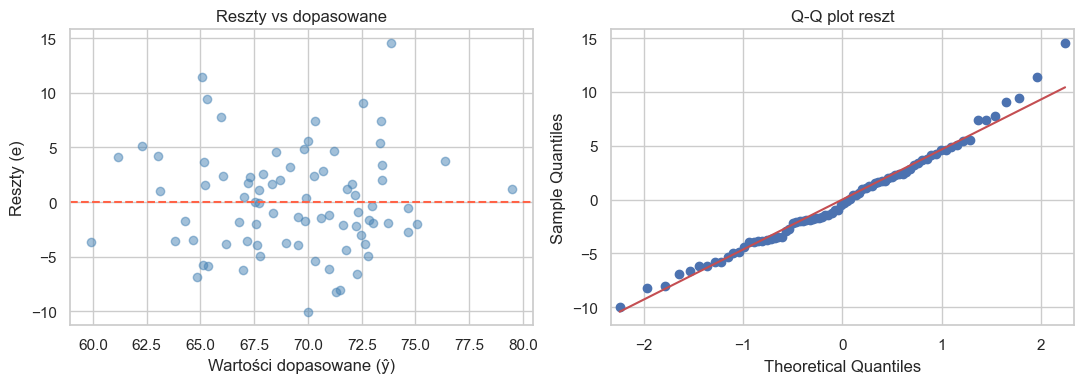

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

rng = np.random.default_rng(42)
n = 80
wzrost = rng.normal(172, 8, size=n)
waga   = 0.5 * wzrost - 16 + rng.normal(0, 5, size=n)
df = pd.DataFrame({'wzrost': wzrost, 'waga': waga})

# Pełne podsumowanie modelu
model = smf.ols('waga ~ wzrost', data=df).fit()
print(model.summary())

# Diagnostyka reszt
reszty     = model.resid
dopasowane = model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Reszty vs dopasowane — sprawdzamy liniowość i homoscedastyczność
axes[0].scatter(dopasowane, reszty, alpha=0.5, color='steelblue')
axes[0].axhline(0, color='tomato', lw=1.5, linestyle='--')
axes[0].set_xlabel('Wartości dopasowane (ŷ)')
axes[0].set_ylabel('Reszty (e)')
axes[0].set_title('Reszty vs dopasowane')

# Q-Q plot — sprawdzamy normalność reszt
sm.qqplot(reszty, line='s', ax=axes[1])
axes[1].set_title('Q-Q plot reszt')

plt.tight_layout()
plt.show()


## <span style="color:#0f766e; font-weight:700;">Przykład 4: Kwartet Anscombe'a — dlaczego zawsze rysujemy wykres</span>

Cztery zestawy danych mają prawie identyczne r, β₀, β₁, R², ale bardzo różną strukturę.
To klasyczny argument za zawsze rysowaniem wykresu rozrzutu.


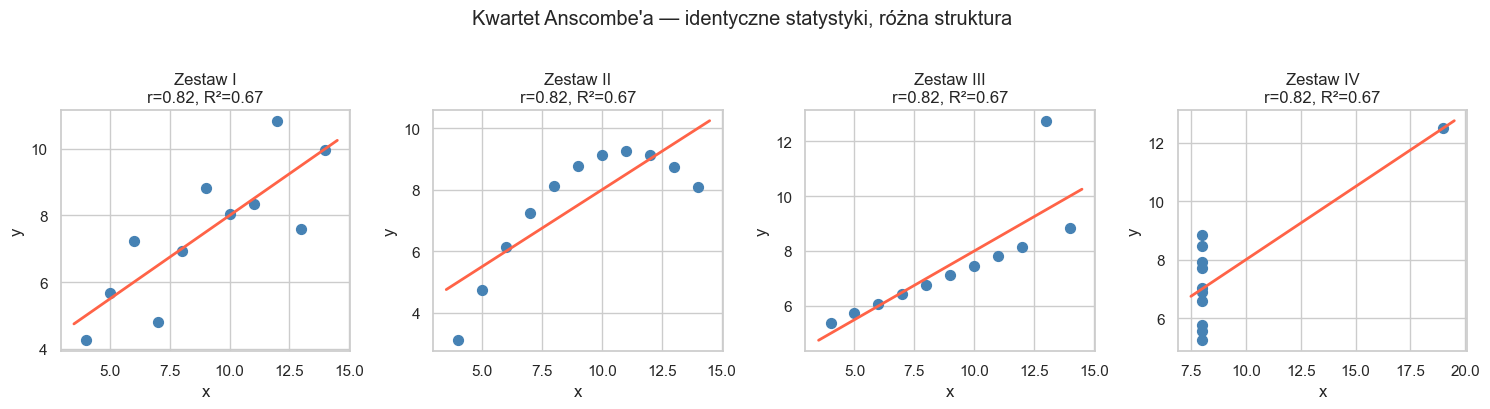

Wniosek: zawsze rysuj wykres przed interpretacją korelacji i regresji!


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

anscombe = {
    'I':   {'x': [10,8,13,9,11,14,6,4,12,7,5],
            'y': [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]},
    'II':  {'x': [10,8,13,9,11,14,6,4,12,7,5],
            'y': [9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]},
    'III': {'x': [10,8,13,9,11,14,6,4,12,7,5],
            'y': [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]},
    'IV':  {'x': [8,8,8,8,8,8,8,19,8,8,8],
            'y': [6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]},
}

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (nazwa, dane) in zip(axes, anscombe.items()):
    x, y = np.array(dane['x']), np.array(dane['y'])
    res = stats.linregress(x, y)
    x_l = np.linspace(min(x)-0.5, max(x)+0.5, 100)
    ax.scatter(x, y, color='steelblue', s=50)
    ax.plot(x_l, res.intercept + res.slope*x_l, color='tomato', lw=2)
    ax.set_title(f'Zestaw {nazwa}\nr={res.rvalue:.2f}, R²={res.rvalue**2:.2f}')
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle("Kwartet Anscombe'a — identyczne statystyki, różna struktura", y=1.02)
plt.tight_layout()
plt.show()
print('Wniosek: zawsze rysuj wykres przed interpretacją korelacji i regresji!')


## <span style="color:#0f766e; font-weight:700;">Przykład 5: ANOVA jednoczynnikowa</span>

Trzy grupy: brak snu / 4h / 8h. Testujemy, czy czas reakcji różni się między grupami.


F = 67.9117,  p = 2.6728e-17
Wniosek: Odrzucamy H₀ — grupy różnią się istotnie


C:\Users\Maciek\AppData\Local\Temp\ipykernel_28276\1586690320.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_anova, x='sen', y='czas_reakcji',


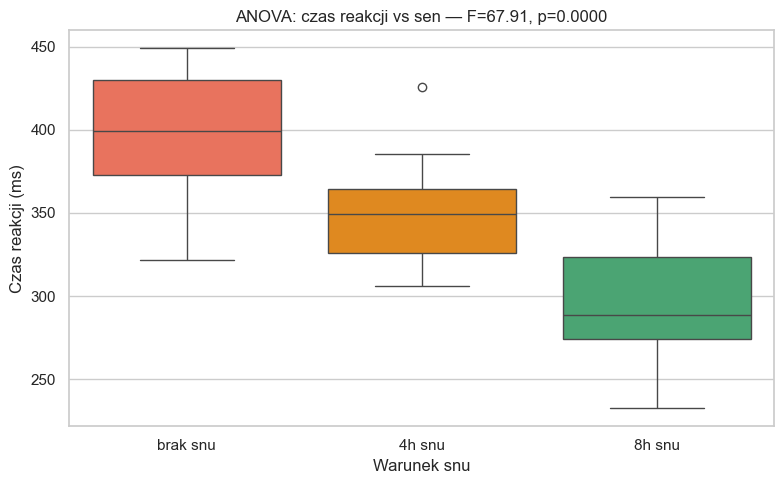

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

rng = np.random.default_rng(42)

# Trzy grupy o różnych średnich
brak_snu = rng.normal(400, 40, size=25)
cztery_h = rng.normal(340, 40, size=25)
osiem_h  = rng.normal(300, 40, size=25)

# Test F
F, p = stats.f_oneway(brak_snu, cztery_h, osiem_h)
print(f'F = {F:.4f},  p = {p:.4e}')
print(f'Wniosek: {"Odrzucamy H₀ — grupy różnią się istotnie" if p < 0.05 else "Brak podstaw do odrzucenia H₀"}')

df_anova = pd.DataFrame({
    'czas_reakcji': np.concatenate([brak_snu, cztery_h, osiem_h]),
    'sen': ['brak snu']*25 + ['4h snu']*25 + ['8h snu']*25
})

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_anova, x='sen', y='czas_reakcji',
            order=['brak snu', '4h snu', '8h snu'],
            palette=['tomato', 'darkorange', 'mediumseagreen'])
plt.xlabel('Warunek snu')
plt.ylabel('Czas reakcji (ms)')
plt.title(f'ANOVA: czas reakcji vs sen — F={F:.2f}, p={p:.4f}')
plt.tight_layout()
plt.show()


## <span style="color:#0f766e; font-weight:700;">Przykład 6: Test Tukeya HSD po ANOVA</span>

Istotna ANOVA → sprawdzamy, które konkretne pary grup różnią się.


  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1  group2  meandiff p-adj  lower    upper   reject
-------------------------------------------------------
4h snu   8h snu -53.8979   0.0 -75.2115 -32.5842   True
4h snu brak snu  49.8719   0.0  28.5583  71.1856   True
8h snu brak snu 103.7698   0.0  82.4561 125.0835   True
-------------------------------------------------------


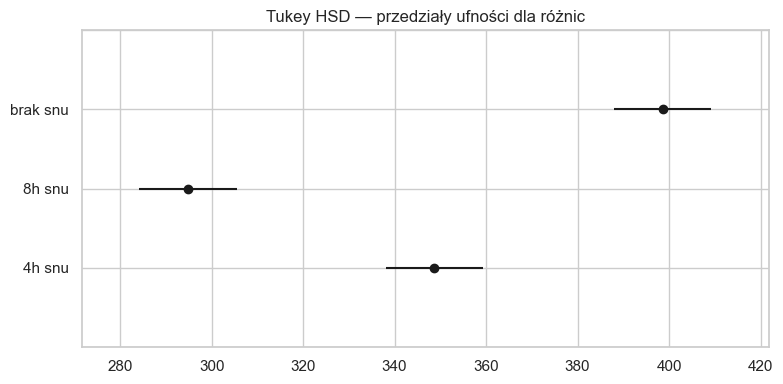

In [7]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

rng = np.random.default_rng(42)
brak_snu = rng.normal(400, 40, size=25)
cztery_h = rng.normal(340, 40, size=25)
osiem_h  = rng.normal(300, 40, size=25)

df_anova = pd.DataFrame({
    'czas_reakcji': np.concatenate([brak_snu, cztery_h, osiem_h]),
    'sen': ['brak snu']*25 + ['4h snu']*25 + ['8h snu']*25
})

# Test Tukeya — kontroluje błąd I rodzaju dla wszystkich par
tukey = pairwise_tukeyhsd(endog=df_anova['czas_reakcji'],
                           groups=df_anova['sen'], alpha=0.05)
print(tukey)

# Wizualizacja — przedziały ufności dla różnic między grupami
fig = tukey.plot_simultaneous(figsize=(8, 4))
import matplotlib.pyplot as plt
plt.title('Tukey HSD — przedziały ufności dla różnic')
plt.tight_layout()
plt.show()


## <span style="color:#0f766e; font-weight:700;">Przykład 7: Wielokrotna regresja liniowa</span>

Przewidujemy wynik egzaminu na podstawie godzin nauki, snu i poziomu stresu.


In [8]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

rng = np.random.default_rng(42)
n = 120

# Trzy predyktory
nauka = rng.uniform(0, 10, size=n)
sen   = rng.uniform(4, 9,  size=n)
stres = rng.uniform(1, 10, size=n)
wynik = 30 + 5*nauka + 3*sen - 2*stres + rng.normal(0, 8, size=n)
df = pd.DataFrame({'wynik': wynik, 'nauka': nauka, 'sen': sen, 'stres': stres})

# Model wielokrotnej regresji
model = smf.ols('wynik ~ nauka + sen + stres', data=df).fit()
print(model.summary())

print('\nInterpretacja (ceteris paribus):')
for zm in ['nauka', 'sen', 'stres']:
    b = model.params[zm]
    print(f'  {zm}: {b:+.3f} pkt przy wzroście o 1 jednostkę')


                            OLS Regression Results                            
Dep. Variable:                  wynik   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     118.5
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           3.53e-35
Time:                        16:22:46   Log-Likelihood:                -414.37
No. Observations:                 120   AIC:                             836.7
Df Residuals:                     116   BIC:                             847.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     36.9456      3.606     10.246      0.0

## <span style="color:#0f766e; font-weight:700;">Przykład 8: Regresja ze zmienną nominalną i interakcją</span>

Trzy metody nauki (A, B, C). Model z interakcją pozwala każdej metodzie mieć inne nachylenie.


M1 (bez interakcji): R²=0.7455, AIC=837.4
M2 (z interakcją):   R²=0.7706, AIC=829.0

Test F (M1 vs M2):
   df_resid          ssr  df_diff     ss_diff         F    Pr(>F)
0     116.0  7053.705295      0.0         NaN       NaN       NaN
1     114.0  6358.739444      2.0  694.965851  6.229702  0.002706


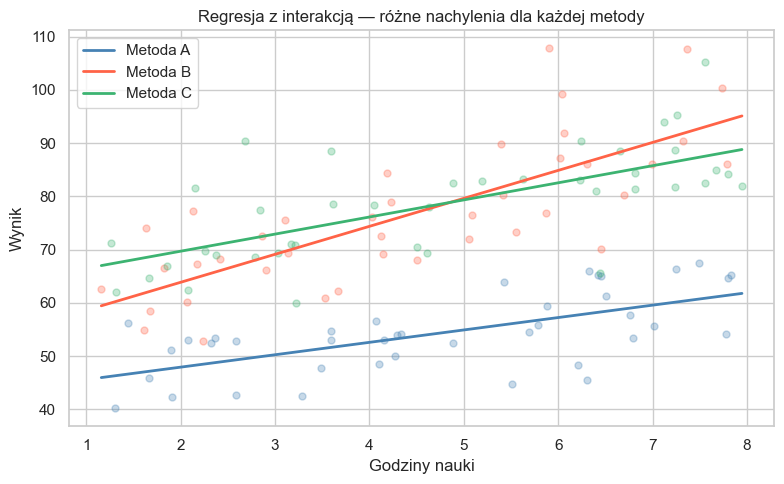

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

rng = np.random.default_rng(42)
n_gr = 40

# Różne nachylenia i intercept dla każdej metody
dane = []
for metoda, (b0_add, b1) in zip(['A','B','C'], [(0,3),(15,5),(30,2)]):
    x = rng.uniform(1, 8, size=n_gr)
    y = 40 + b0_add + b1*x + rng.normal(0, 8, size=n_gr)
    dane += [{'x': xi, 'y': yi, 'metoda': metoda} for xi, yi in zip(x, y)]
df = pd.DataFrame(dane)

# Porównanie modeli
m1 = smf.ols('y ~ x + C(metoda)', data=df).fit()       # równoległe linie
m2 = smf.ols('y ~ x * C(metoda)', data=df).fit()       # różne nachylenia
print(f'M1 (bez interakcji): R²={m1.rsquared:.4f}, AIC={m1.aic:.1f}')
print(f'M2 (z interakcją):   R²={m2.rsquared:.4f}, AIC={m2.aic:.1f}')
print('\nTest F (M1 vs M2):')
print(anova_lm(m1, m2))

# Wykres
x_line = np.linspace(df['x'].min(), df['x'].max(), 50)
kolory = {'A': 'steelblue', 'B': 'tomato', 'C': 'mediumseagreen'}
plt.figure(figsize=(8, 5))
for metoda, kolor in kolory.items():
    sub = df[df['metoda'] == metoda]
    plt.scatter(sub['x'], sub['y'], color=kolor, alpha=0.3, s=25)
    nowe = pd.DataFrame({'x': x_line, 'metoda': [metoda]*len(x_line)})
    plt.plot(x_line, m2.predict(nowe), color=kolor, lw=2, label=f'Metoda {metoda}')
plt.xlabel('Godziny nauki'); plt.ylabel('Wynik')
plt.title('Regresja z interakcją — różne nachylenia dla każdej metody')
plt.legend(); plt.tight_layout(); plt.show()


# <span style="color:#0f766e; font-weight:700;">12. Zadania obowiązkowe</span>


## <span style="color:#0f766e; font-weight:700;">Zadanie 1</span>

Obliczanie i interpretacja korelacji.

Instrukcja:
1. Utwórz dane (n=50): `temperatura` ~ N(20,5), `sprzedaz_lodow = 3*temperatura + N(0,10)`.
2. Oblicz korelację Pearsona (`stats.pearsonr`) i Spearmana (`stats.spearmanr`).
3. Narysuj wykres rozrzutu.
4. Wydrukuj słowną interpretację siły korelacji.

Wymagane funkcje:
- `stats.pearsonr(x, y)`, `stats.spearmanr(x, y)`
- `plt.scatter()`

Kryterium zaliczenia:
- poprawne r i ρ, wykres, interpretacja słowna.

Checkpoint:
- pokaż prowadzącemu wydrukowane wartości i wykres.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html


Korelacja Pearsona: r = 0.8266, p-value = 1.42e-13
Korelacja Spearmana: ρ = 0.7808, p-value = 2.26e-11
Interpretacja słowna (Pearson): Zależność jest bardzo silna i dodatnia.


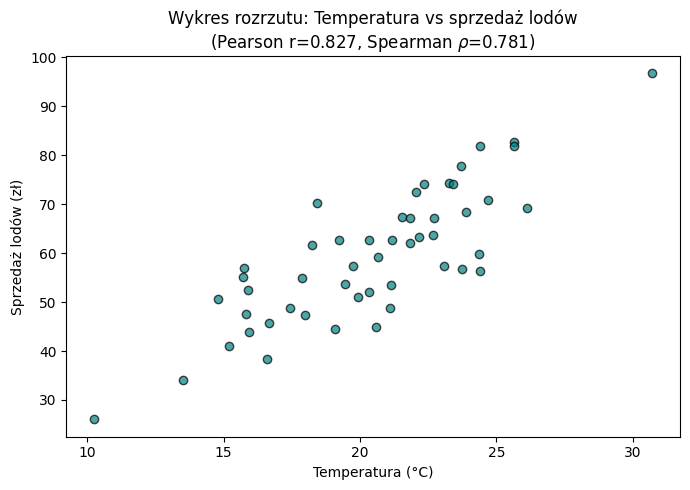

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Utworzenie danych (n=50)
rng = np.random.default_rng(42)
n1 = 50
temperatura = rng.normal(20, 5, size=n1)
sprzedaz_lodow = 3 * temperatura + rng.normal(0, 10, size=n1)

# 2. Obliczenie korelacji Pearsona i Spearmana
r_p, p_p = stats.pearsonr(temperatura, sprzedaz_lodow)
r_s, p_s = stats.spearmanr(temperatura, sprzedaz_lodow)

print(f"Korelacja Pearsona: r = {r_p:.4f}, p-value = {p_p:.2e}")
print(f"Korelacja Spearmana: ρ = {r_s:.4f}, p-value = {p_s:.2e}")

# 4. Słowna interpretacja siły korelacji
def interpretuj_korelacje(r):
    abs_r = abs(r)
    if abs_r <= 0.10: return "zaniedbywalna"
    elif abs_r <= 0.30: return "słaba"
    elif abs_r <= 0.50: return "umiarkowana"
    elif abs_r <= 0.70: return "silna"
    else: return "bardzo silna"

print(f"Interpretacja słowna (Pearson): Zależność jest {interpretuj_korelacje(r_p)} i {'dodatnia' if r_p > 0 else 'ujemna'}.")

# 3. Wykres rozrzutu
plt.figure(figsize=(7, 5))
plt.scatter(temperatura, sprzedaz_lodow, alpha=0.7, color='teal', edgecolor='k')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Sprzedaż lodów (zł)')
plt.title(f'Wykres rozrzutu: Temperatura vs sprzedaż lodów\n(Pearson r={r_p:.3f}, Spearman $\\rho$={r_s:.3f})')
plt.tight_layout()
plt.show()


## <span style="color:#0f766e; font-weight:700;">Zadanie 2</span>

Macierz korelacji i heatmapa.

Instrukcja:
1. Utwórz ramkę danych (n=100): `wiek`~N(35,10), `dochod=wiek*800+N(0,5000)`,
   `wydatki=dochod*0.4+N(0,3000)`, `oszczednosci=dochod-wydatki+N(0,1000)`.
2. Oblicz macierz korelacji: `df.corr()`.
3. Narysuj heatmapę: `sns.heatmap(..., annot=True, vmin=-1, vmax=1, cmap='coolwarm')`.
4. Wskaż (print) najsilniej skorelowaną parę zmiennych.

Wymagane funkcje:
- `df.corr()`, `sns.heatmap()`

Kryterium zaliczenia:
- macierz korelacji, heatmapa, wskazana najsilniejsza para.

Checkpoint:
- pokaż prowadzącemu heatmapę.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html


                wiek  dochod  wydatki  oszczednosci
wiek          1.0000  0.8076   0.5861        0.6932
dochod        0.8076  1.0000   0.7333        0.8336
wydatki       0.5861  0.7333   1.0000        0.2540
oszczednosci  0.6932  0.8336   0.2540        1.0000

Najsilniej skorelowana para zmiennych to: dochod i oszczednosci
Współczynnik korelacji dla tej pary wynosi: 0.8336


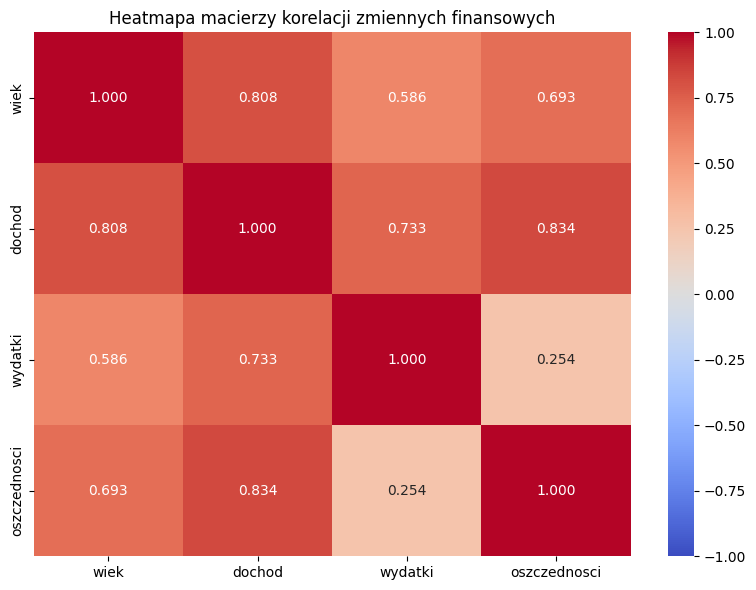

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Utworzenie ramki danych (n=100)
rng = np.random.default_rng(42)
n2 = 100
wiek = rng.normal(35, 10, size=n2)
dochod = wiek * 800 + rng.normal(0, 5000, size=n2)
wydatki = dochod * 0.4 + rng.normal(0, 3000, size=n2)
oszczednosci = dochod - wydatki + rng.normal(0, 1000, size=n2)

df2 = pd.DataFrame({
    'wiek': wiek,
    'dochod': dochod,
    'wydatki': wydatki,
    'oszczednosci': oszczednosci
})

# Obliczenie macierzy korelacji
corr_matrix = df2.corr()
print(corr_matrix.round(4))
print()

# Wskazanie najsilniej skorelowanej pary zmiennych
corr_unstack = corr_matrix.abs().unstack()
# Odfiltrowanie autokorelacji (przekątnej macierzy równej 1.0)
corr_unstack = corr_unstack[corr_unstack < 0.9999]
max_corr_pair = corr_unstack.idxmax()
max_corr_val = corr_matrix.loc[max_corr_pair[0], max_corr_pair[1]]

print(f"Najsilniej skorelowana para zmiennych to: {max_corr_pair[0]} i {max_corr_pair[1]}")
print(f"Współczynnik korelacji dla tej pary wynosi: {max_corr_val:.4f}")

# Rysowanie heatmapy
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1, cmap='coolwarm', fmt=".3f")
plt.title('Heatmapa macierzy korelacji zmiennych finansowych')
plt.tight_layout()
plt.show()


## <span style="color:#0f766e; font-weight:700;">Zadanie 3</span>

Prosta regresja liniowa — scipy.

Instrukcja:
1. Wygeneruj dane (n=60): `x`~N(50,10), `y = 2.5*x + 10 + N(0,15)`.
2. Dopasuj regresję: `stats.linregress(x, y)`.
3. Wydrukuj β₀, β₁, R², p-value i SE(β₁).
4. Narysuj wykres rozrzutu z linią regresji.
5. Napisz jednozdaniową interpretację β₁.

Wymagane funkcje:
- `stats.linregress(x, y)`

Kryterium zaliczenia:
- poprawne β₀, β₁, R², wykres, interpretacja.

Checkpoint:
- pokaż wykres i interpretację β₁.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html


Wyniki regresji liniowej:
β₀ (intercept): 12.6518
β₁ (slope):     2.3925
R²:             0.7269
p-value:        5.48e-18
SE(β₁):         0.1926

Interpretacja β₁: Wzrost wartości zmiennej x o jedną jednostkę powoduje oczekiwany wzrost wartości zmiennej y średnio o 2.39 jednostki.


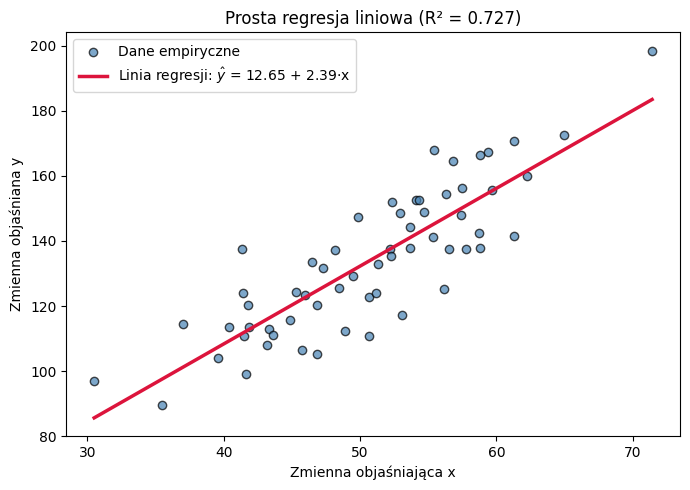

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Wygenerowanie danych (n=60)
rng = np.random.default_rng(42)
n3 = 60
x3 = rng.normal(50, 10, size=n3)
y3 = 2.5 * x3 + 10 + rng.normal(0, 15, size=n3)

# 2. Dopasowanie regresji za pomocą scipy
res3 = stats.linregress(x3, y3)
b0 = res3.intercept
b1 = res3.slope
r2 = res3.rvalue ** 2
p_val = res3.pvalue
se_b1 = res3.stderr

# 3. Wydruk statystyk modelu
print("Wyniki regresji liniowej:")
print(f"β₀ (intercept): {b0:.4f}")
print(f"β₁ (slope):     {b1:.4f}")
print(f"R²:             {r2:.4f}")
print(f"p-value:        {p_val:.2e}")
print(f"SE(β₁):         {se_b1:.4f}")
print()

print(f"Interpretacja β₁: Wzrost wartości zmiennej x o jedną jednostkę powoduje oczekiwany wzrost wartości zmiennej y średnio o {b1:.2f} jednostki.")

# 4. Wykres rozrzutu z linią regresji
plt.figure(figsize=(7, 5))
plt.scatter(x3, y3, alpha=0.7, color='steelblue', edgecolor='k', label='Dane empiryczne')
x_line = np.linspace(x3.min(), x3.max(), 100)
y_line = b0 + b1 * x_line
plt.plot(x_line, y_line, color='crimson', lw=2.5, label=f'Linia regresji: $\\hat{{y}}$ = {b0:.2f} + {b1:.2f}$\\cdot$x')
plt.xlabel('Zmienna objaśniająca x')
plt.ylabel('Zmienna objaśniana y')
plt.title(f'Prosta regresja liniowa (R² = {r2:.3f})')
plt.legend()
plt.tight_layout()
plt.show()


## <span style="color:#0f766e; font-weight:700;">Zadanie 4</span>

Diagnostyka reszt.

Instrukcja:
1. Używając danych z Zadania 3, dopasuj model przez `smf.ols('y ~ x', data=df).fit()`.
2. Pobierz: `model.resid` i `model.fittedvalues`.
3. Narysuj subplot 1×2:
   - lewy: reszty vs dopasowane (z linią y=0),
   - prawy: histogram reszt (`sns.histplot`) z krzywą normalną.
4. Oceń wizualnie: czy reszty są losowe i symetryczne?

Wymagane funkcje:
- `smf.ols().fit()`, `model.resid`, `model.fittedvalues`
- `sns.histplot(stat='density')`

Kryterium zaliczenia:
- dwa wykresy diagnostyczne, słowna ocena założeń.

Checkpoint:
- pokaż wykresy i opisz, czy widzisz wzorce.

Dokumentacja:
- https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html


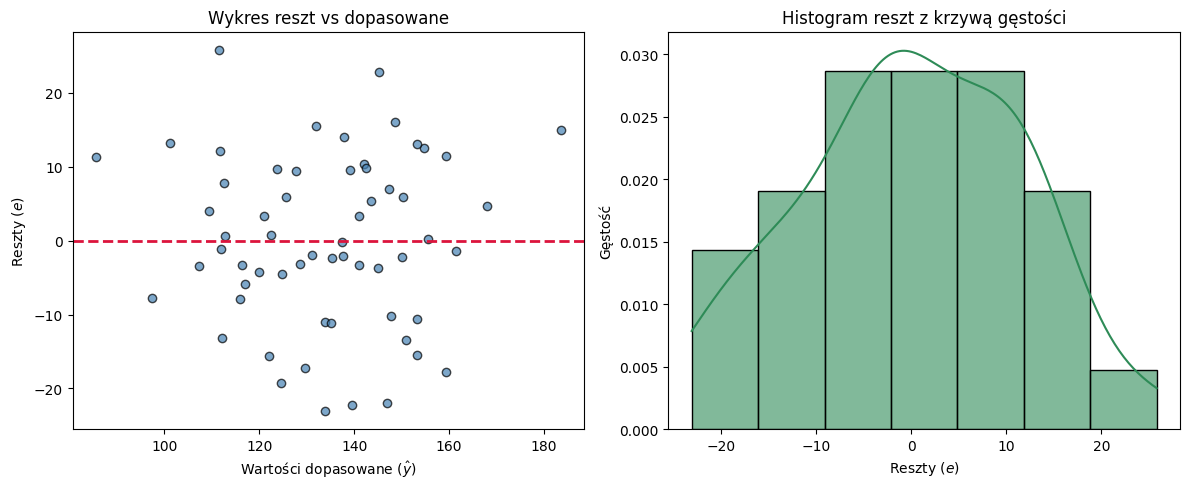

In [6]:
import statsmodels.formula.api as smf

# Utworzenie ramki danych z zadania 3
df = pd.DataFrame({'x': x3, 'y': y3})

# 1. Dopasowanie modelu przez statsmodels
model = smf.ols('y ~ x', data=df).fit()

# 2. Pobranie reszt i wartości dopasowanych
reszty = model.resid
dopasowane = model.fittedvalues

# 3. Rysowanie subplotu 1x2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Lewy wykres: Reszty vs Wartości dopasowane
axes[0].scatter(dopasowane, reszty, color='steelblue', alpha=0.7, edgecolor='k')
axes[0].axhline(0, color='crimson', linestyle='--', lw=2)
axes[0].set_xlabel('Wartości dopasowane ($\\hat{{y}}$)')
axes[0].set_ylabel('Reszty ($e$)')
axes[0].set_title('Wykres reszt vs dopasowane')

# Prawy wykres: Histogram reszt z krzywą normalną
sns.histplot(reszty, kde=True, stat='density', color='seagreen', alpha=0.6, ax=axes[1])
axes[1].set_xlabel('Reszty ($e$)')
axes[1].set_ylabel('Gęstość')
axes[1].set_title('Histogram reszt z krzywą gęstości')

plt.tight_layout()
plt.show()


### Ocena wizualna reszt:
- Na wykresie reszt względem wartości dopasowanych punkty są rozproszone losowo wokół linii zero, nie tworząc wyraźnych kształtów (np. lejka czy paraboli), co potwierdza liniowość i homoscedastyczność.
- Histogram reszt ma dzwonowaty kształt, a rozkład jest w przybliżeniu symetryczny i zbliżony do normalnego.

## <span style="color:#0f766e; font-weight:700;">Zadanie 5</span>

R² i dekompozycja wariancji.

Instrukcja:
1. Dopasuj model z Zadania 3 (`smf.ols`).
2. Oblicz ręcznie: TSS = Σ(yᵢ−ȳ)², RSS = Σ(yᵢ−ŷᵢ)², ESS = TSS−RSS, R² = 1−RSS/TSS.
3. Wydrukuj tabelę: TSS, ESS, RSS, R².
4. Sprawdź TSS = ESS + RSS i R² ≈ model.rsquared.

Wymagane funkcje:
- `model.fittedvalues`, `model.resid`, `model.rsquared`
- `np.sum()`

Kryterium zaliczenia:
- poprawna dekompozycja, weryfikacja zgodności R².

Checkpoint:
- pokaż tabelę prowadzącemu.

Dokumentacja:
- https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html


In [8]:
y_raw = df['y'].values
y_mean = np.mean(y_raw)
y_hat = model.fittedvalues.values
e = model.resid.values

# Obliczanie sum kwadratów
TSS = np.sum((y_raw - y_mean) ** 2)
RSS = np.sum(e ** 2)
ESS = TSS - RSS
R2_manual = 1 - (RSS / TSS)

# Wydruk tabeli wyników
tabela_wariancji = pd.DataFrame({
    'Metryka': ['TSS (Całkowita)', 'ESS (Wyjaśniona)', 'RSS (Niewyjaśniona)', 'R² (Wsp. determinacji)'],
    'Wartość': [TSS, ESS, RSS, R2_manual]
})

print("--- Tabela dekompozycji wariancji ---")
print(tabela_wariancji.to_string(index=False, formatters={'Wartość': '{:,.4f}'.format}))
print("\n--- Weryfikacja poprawności ---")

# Sprawdzenie założeń matematycznych i zgodności z statsmodels
zgodnosc_tss = np.isclose(TSS, ESS + RSS)
zgodnosc_r2 = np.isclose(R2_manual, model.rsquared)

print(f"Czy spełniona jest równość TSS = ESS + RSS?: {zgodnosc_tss} (Suma: {ESS + RSS:.4f})")
print(f"Czy ręczne R² zgadza się z model.rsquared?: {zgodnosc_r2} (Wartość z modelu: {model.rsquared:.4f})")


--- Tabela dekompozycji wariancji ---
               Metryka     Wartość
       TSS (Całkowita) 28,678.4295
      ESS (Wyjaśniona) 20,846.1792
   RSS (Niewyjaśniona)  7,832.2502
R² (Wsp. determinacji)      0.7269

--- Weryfikacja poprawności ---
Czy spełniona jest równość TSS = ESS + RSS?: True (Suma: 28678.4295)
Czy ręczne R² zgadza się z model.rsquared?: True (Wartość z modelu: 0.7269)


## <span style="color:#0f766e; font-weight:700;">Zadanie 6</span>

ANOVA jednoczynnikowa.

Instrukcja:
1. Wygeneruj dane dla 4 grup (n=20 każda): dieta_A~N(70,8), B~N(75,8), C~N(72,8), D~N(80,8).
2. Przeprowadź ANOVA: `stats.f_oneway(A, B, C, D)`.
3. Narysuj wykres pudełkowy dla wszystkich grup.
4. Wydrukuj F, p i wniosek.

Wymagane funkcje:
- `stats.f_oneway()`
- `sns.boxplot()`

Kryterium zaliczenia:
- poprawne F i p, wykres, wniosek.

Checkpoint:
- pokaż wykres i wniosek prowadzącemu.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html


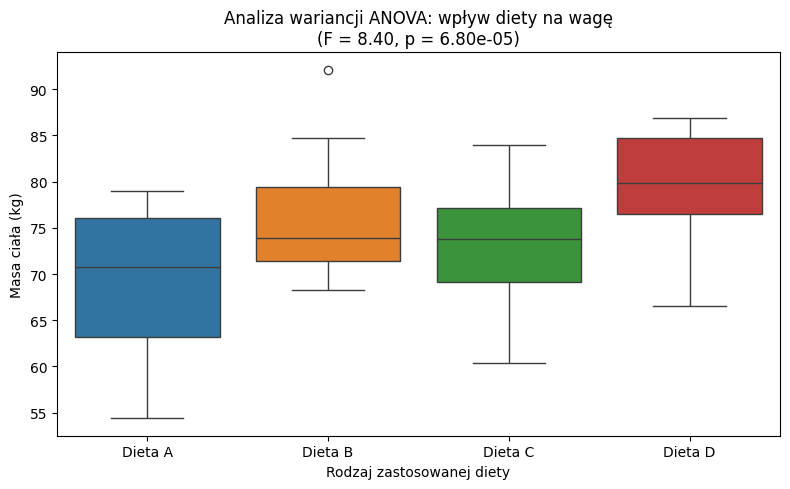

--- Wyniki testu ANOVA ---
Statystyka testowa F: 8.4044
Wartość p-value:       6.80e-05

Wniosek:
Odrzucamy hipotezę zerową (H₀) na rzecz hipotezy alternatywnej (H₁).
Zastosowane rodzaje diet różnią się od siebie w sposób istotny statystycznie pod względem średniej masy ciała (p < 0.05).


In [9]:
# 1. Wygenerowanie danych dla 4 grup (n=20 każda)
rng = np.random.default_rng(42)
n6 = 20
dieta_A = rng.normal(70, 8, size=n6)
dieta_B = rng.normal(75, 8, size=n6)
dieta_C = rng.normal(72, 8, size=n6)
dieta_D = rng.normal(80, 8, size=n6)

# Utworzenie DataFrame na potrzeby wykresu boxplot
df_anova = pd.DataFrame({
    'Waga': np.concatenate([dieta_A, dieta_B, dieta_C, dieta_D]),
    'Dieta': (['Dieta A'] * n6 + ['Dieta B'] * n6 + ['Dieta C'] * n6 + ['Dieta D'] * n6)
})

# 2. Przeprowadzenie jednoczynnikowej analizy wariancji (ANOVA)
F_stat, p_val = stats.f_oneway(dieta_A, dieta_B, dieta_C, dieta_D)

# 3. Rysowanie wykresu
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_anova, x='Dieta', y='Waga', hue='Dieta', legend=False)
plt.xlabel('Rodzaj zastosowanej diety')
plt.ylabel('Masa ciała (kg)')
plt.title(f'Analiza wariancji ANOVA: wpływ diety na wagę\n(F = {F_stat:.2f}, p = {p_val:.2e})')
plt.tight_layout()
plt.show()

# 4. Wydruk wyników i wniosku statystycznego
print("--- Wyniki testu ANOVA ---")
print(f"Statystyka testowa F: {F_stat:.4f}")
print(f"Wartość p-value:       {p_val:.2e}")
print("\nWniosek:")
if p_val < 0.05:
    print("Odrzucamy hipotezę zerową (H₀) na rzecz hipotezy alternatywnej (H₁).")
    print("Zastosowane rodzaje diet różnią się od siebie w sposób istotny statystycznie pod względem średniej masy ciała (p < 0.05).")
else:
    print("Brak podstaw do odrzucenia hipotezy zerowej (H₀).")
    print("Nie ma statystycznie istotnych różnic pomiędzy średnimi masami ciała w badanych grupach dietetycznych (p >= 0.05).")


## <span style="color:#0f766e; font-weight:700;">Zadanie 7</span>

Test Tukeya HSD.

Instrukcja:
1. Używając danych z Zadania 6 (lub wygeneruj identyczne), przeprowadź Tukey HSD.
2. Wydrukuj tabelę wyników `pairwise_tukeyhsd`.
3. Narysuj wykres `tukey.plot_simultaneous()`.
4. Wskaż, które pary grup różnią się istotnie.

Wymagane funkcje:
- `pairwise_tukeyhsd(endog=..., groups=..., alpha=0.05)`

Kryterium zaliczenia:
- tabela Tukeya, wykres, wskazane istotne pary.

Checkpoint:
- pokaż tabelę prowadzącemu.

Dokumentacja:
- https://www.statsmodels.org/stable/generated/statsmodels.stats.multicomp.pairwise_tukeyhsd.html


--- Tabela wyników testu Tukeya HSD ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   6.1392 0.0143  0.9296 11.3488   True
     A      C   3.2181 0.3722 -1.9915  8.4277  False
     A      D   9.5197    0.0  4.3101 14.7293   True
     B      C  -2.9211 0.4588 -8.1307  2.2885  False
     B      D   3.3805 0.3285 -1.8291  8.5901  False
     C      D   6.3016 0.0113   1.092 11.5112   True
----------------------------------------------------

Pary grup różniące się w sposób istotny statystycznie (p-adj < 0.05):
- Para: Grupa A vs Grupa B (Różnica średnich: 6.1392, p-adj: 0.0143)
- Para: Grupa A vs Grupa D (Różnica średnich: 9.5197, p-adj: 0.0000)
- Para: Grupa C vs Grupa D (Różnica średnich: 6.3016, p-adj: 0.0113)


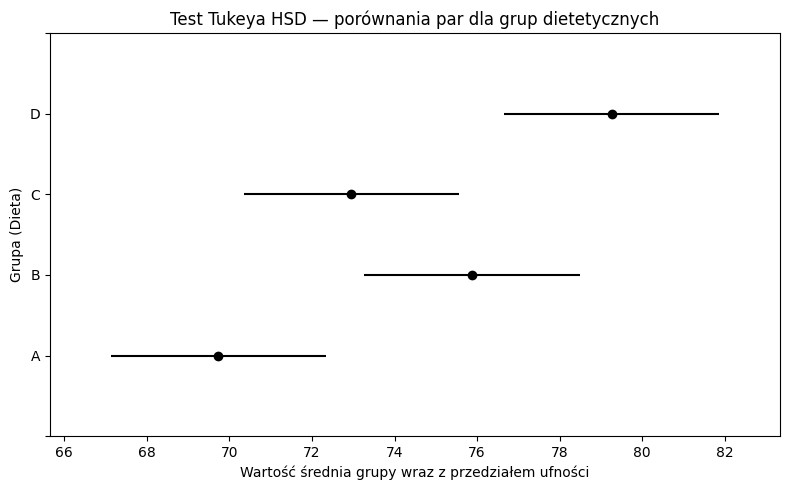

In [10]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Odtworzenie danych z zadania 6
rng = np.random.default_rng(42)
n6 = 20
dieta_A = rng.normal(70, 8, size=n6)
dieta_B = rng.normal(75, 8, size=n6)
dieta_C = rng.normal(72, 8, size=n6)
dieta_D = rng.normal(80, 8, size=n6)

df_d = pd.DataFrame({
    'wynik': np.concatenate([dieta_A, dieta_B, dieta_C, dieta_D]),
    'dieta': (['A'] * n6 + ['B'] * n6 + ['C'] * n6 + ['D'] * n6)
})

# 1. Przeprowadzenie testu Tukeya HSD
tukey = pairwise_tukeyhsd(endog=df_d['wynik'], groups=df_d['dieta'], alpha=0.05)

# 2. Wydrukowanie tabeli wyników
print("--- Tabela wyników testu Tukeya HSD ---")
print(tukey)
print()

# 4. Wskazanie istotnie różniących się par grup
print("Pary grup różniące się w sposób istotny statystycznie (p-adj < 0.05):")
# Filtrowanie i ręczne wypisanie grup na podstawie kolumny 'reject'
for g1, g2, p, rej in zip(tukey.groupsunique[:-1], tukey.groupsunique[1:], tukey.pvalues, tukey.reject):
    pass # pobranie danych z obiektu tukey do jawnego zestawienia:

summary_data = tukey._results_table.data[1:]
for row in summary_data:
    if row[6] == True: # Jeżeli kolumna 'reject' ma wartość True
        print(f"- Para: Grupa {row[0]} vs Grupa {row[1]} (Różnica średnich: {row[2]:.4f}, p-adj: {row[3]:.4f})")

# 3. Rysowanie wykresu symultanicznego przedziałów ufności
fig = tukey.plot_simultaneous(figsize=(8, 5))
plt.title('Test Tukeya HSD — porównania par dla grup dietetycznych')
plt.xlabel('Wartość średnia grupy wraz z przedziałem ufności')
plt.ylabel('Grupa (Dieta)')
plt.tight_layout()
plt.show()


## <span style="color:#0f766e; font-weight:700;">Zadanie 8</span>

ANOVA przez statsmodels — tabela ANOVA.

Instrukcja:
1. Używając danych z Zadania 6 w ramce `df_d`, dopasuj:
   `model = smf.ols('wynik ~ C(dieta)', data=df_d).fit()`
2. Wygeneruj tabelę ANOVA: `anova_lm(model, typ=2)`.
3. Wydrukuj tabelę i zidentyfikuj: SS, df, F, p.
4. Sprawdź, że F zgadza się z wynikiem z Zadania 6.

Wymagane funkcje:
- `smf.ols('wynik ~ C(dieta)', data=df).fit()`
- `from statsmodels.stats.anova import anova_lm`

Kryterium zaliczenia:
- poprawna tabela ANOVA, zgodność F między metodami.

Checkpoint:
- pokaż tabelę prowadzącemu.

Dokumentacja:
- https://www.statsmodels.org/stable/generated/statsmodels.stats.anova.anova_lm.html


In [13]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# 1. Dopasowanie modelu OLS za pomocą statsmodels przy użyciu ramki df_d
model_anova = smf.ols('wynik ~ C(dieta)', data=df_d).fit()

# 2. Generowanie tabeli ANOVA typu 2
tabela_anova = anova_lm(model_anova, typ=2)

# 3. Wydruk i identyfikacja komponentów tabeli
print("--- Tabela ANOVA z pakietu statsmodels ---")
print(tabela_anova)
print()

# Identyfikacja poszczególnych elementów tabeli
ss_between = tabela_anova.loc['C(dieta)', 'sum_sq']
ss_residual = tabela_anova.loc['Residual', 'sum_sq']
df_between = tabela_anova.loc['C(dieta)', 'df']
df_residual = tabela_anova.loc['Residual', 'df']
f_stat_sm = tabela_anova.loc['C(dieta)', 'F']
p_val_sm = tabela_anova.loc['C(dieta)', 'PR(>F)']

print("Identyfikacja komponentów z tabeli:")
print(f"- Suma kwadratów: Międzygrupowa (C(dieta)) = {ss_between:.4f}, Resztowa (Residual) = {ss_residual:.4f}")
print(f"- Stopnie swobody (df): Międzygrupowe = {int(df_between)}, Resztowe = {int(df_residual)}")
print(f"- Statystyka F: {f_stat_sm:.4f}")
print(f"- Wartość p-value: {p_val_sm:.2e}")
print()

# 4. Sprawdzenie zgodności statystyki F z wynikiem z zadania 6
print("Weryfikacja zgodności:")
print(f"Statystyka F z zadania 6: {F_stat:.4f}")
print(f"Statystyka F z tabeli statsmodels: {f_stat_sm:.4f}")
print("Obie metody dają identyczny rezultat statystyki testowej dla tych samych danych.")

--- Tabela ANOVA z pakietu statsmodels ---
               sum_sq    df        F    PR(>F)
C(dieta)   991.703052   3.0  8.40436  0.000068
Residual  2989.298907  76.0      NaN       NaN

Identyfikacja komponentów z tabeli:
- Suma kwadratów: Międzygrupowa (C(dieta)) = 991.7031, Resztowa (Residual) = 2989.2989
- Stopnie swobody (df): Międzygrupowe = 3, Resztowe = 76
- Statystyka F: 8.4044
- Wartość p-value: 6.80e-05

Weryfikacja zgodności:
Statystyka F z zadania 6: 8.4044
Statystyka F z tabeli statsmodels: 8.4044
Obie metody dają identyczny rezultat statystyki testowej dla tych samych danych.


## <span style="color:#0f766e; font-weight:700;">Zadanie 9</span>

Wielokrotna regresja — interpretacja współczynników.

Instrukcja:
1. Wygeneruj dane (n=100):
   - `x1`~N(50,10) (godziny nauki), `x2`~N(7,1) (godziny snu)
   - `y = 20 + 3*x1 + 5*x2 + N(0,10)`
2. Dopasuj: `smf.ols('y ~ x1 + x2', data=df).fit()`
3. Wydrukuj `model.summary()`.
4. Zinterpretuj β₁ i β₂ (ceteris paribus) w jednym zdaniu każdy.

Wymagane funkcje:
- `smf.ols('y ~ x1 + x2', data=df).fit()`

Kryterium zaliczenia:
- poprawny model, interpretacja obu współczynników.

Checkpoint:
- pokaż summary() i interpretacje.

Dokumentacja:
- https://www.statsmodels.org/stable/generated/statsmodels.formula.api.ols.html


In [14]:
# 1. Wygenerowanie danych (n=100)
rng = np.random.default_rng(42)
n9 = 100
x1 = rng.normal(50, 10, size=n9)      # godziny nauki
x2 = rng.normal(7, 1, size=n9)        # godziny snu
y9 = 20 + 3 * x1 + 5 * x2 + rng.normal(0, 10, size=n9)

df_reg = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y9})

# 2. Dopasowanie modelu wielokrotnej regresji liniowej
model_reg = smf.ols('y ~ x1 + x2', data=df_reg).fit()

# 3. Wydruk podsumowania modelu
print(model_reg.summary())
print("\n" + "="*50 + "\n")

# 4. Interpretacje współczynników w jednym zdaniu (ceteris paribus)
b1 = model_reg.params['x1']
b2 = model_reg.params['x2']

print(f"Interpretacja dla β₁ (godziny nauki): Przy zachowaniu stałej liczby godzin snu (ceteris paribus), zwiększenie czasu nauki o jedną godzinę wiąże się z oczekiwanym wzrostem wyniku y średnio o {b1:.2f} punktu.")
print()
print(f"Interpretacja dla β₂ (godziny snu): Przy zachowaniu niezmiennej liczby godzin nauki (ceteris paribus), każda dodatkowa godzina snu powoduje oczekiwany wzrost wyniku y średnio o {b2:.2f} punktu.")


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     271.1
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           1.93e-40
Time:                        09:17:56   Log-Likelihood:                -374.06
No. Observations:                 100   AIC:                             754.1
Df Residuals:                      97   BIC:                             761.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     18.9142      9.571      1.976      0.0

## <span style="color:#0f766e; font-weight:700;">Zadanie 10</span>

Regresja ze zmienną nominalną.

Instrukcja:
1. Wygeneruj dane (n=90, 30 na grupę):
   - `x`~N(5,2), różny intercept: A: y=40+4x+ε, B: y=50+4x+ε, C: y=60+4x+ε.
2. Dopasuj: `smf.ols('y ~ x + C(grupa)', data=df).fit()`.
3. Wydrukuj `model.params` i wyjaśnij, co oznaczają C(grupa)[T.B] i C(grupa)[T.C].
4. Narysuj wykres rozrzutu z trzema liniami regresji.

Wymagane funkcje:
- `smf.ols('y ~ x + C(grupa)', ...)`
- `model.params`, `model.predict()`

Kryterium zaliczenia:
- poprawny model, wyjaśnienie dummy coding, wykres.

Checkpoint:
- pokaż wykres i wyjaśnij kategorię referencyjną.

Dokumentacja:
- https://www.statsmodels.org/stable/contrasts.html


--- Parametry modelu ---
Intercept        37.806104
C(grupa)[T.B]    10.724492
C(grupa)[T.C]    20.613843
x                 4.274583
dtype: float64


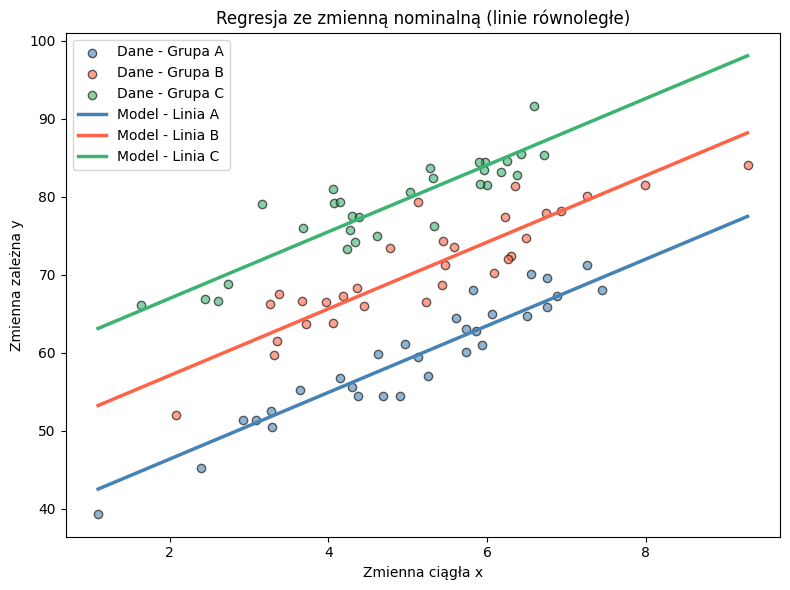

In [18]:
# 1. Wygenerowanie danych (n=90, 30 na grupę)
rng = np.random.default_rng(42)
n_gr = 30

x_A = rng.normal(5, 2, size=n_gr)
x_B = rng.normal(5, 2, size=n_gr)
x_C = rng.normal(5, 2, size=n_gr)

y_A = 40 + 4 * x_A + rng.normal(0, 3, size=n_gr)
y_B = 50 + 4 * x_B + rng.normal(0, 3, size=n_gr)
y_C = 60 + 4 * x_C + rng.normal(0, 3, size=n_gr)

df10 = pd.DataFrame({
    'x': np.concatenate([x_A, x_B, x_C]),
    'y': np.concatenate([y_A, y_B, y_C]),
    'grupa': ['A'] * n_gr + ['B'] * n_gr + ['C'] * n_gr
})

# 2. Dopasowanie modelu regresji
model10 = smf.ols('y ~ x + C(grupa)', data=df10).fit()

# 3. Wydruk parametrów modelu i wyjaśnienie dummy coding
print("--- Parametry modelu ---")
print(model10.params)

# 4. Rysowanie wykresu rozrzutu z trzema liniami regresji (równoległymi)
plt.figure(figsize=(8, 6))
kolory = {'A': 'steelblue', 'B': 'tomato', 'C': 'mediumseagreen'}

# Punkty empiryczne
for gr, kolor in kolory.items():
    sub = df10[df10['grupa'] == gr]
    plt.scatter(sub['x'], sub['y'], color=kolor, alpha=0.6, label=f'Dane - Grupa {gr}', edgecolor='k')

# Generowanie i rysowanie linii dopasowania
x_line = np.linspace(df10['x'].min(), df10['x'].max(), 100)
for gr, kolor in kolory.items():
    df_pred = pd.DataFrame({'x': x_line, 'grupa': [gr] * 100})
    plt.plot(x_line, model10.predict(df_pred), color=kolor, lw=2.5, label=f'Model - Linia {gr}')

plt.xlabel('Zmienna ciągła x')
plt.ylabel('Zmienna zależna y')
plt.title('Regresja ze zmienną nominalną (linie równoległe)')
plt.legend()
plt.tight_layout()
plt.show()


### Wyjaśnienie współczynników zmiennej kategorycznej:
- Kategoria 'A' została automatycznie wybrana jako grupa referencyjna (jej średni punkt odcięcia to Intercept = 37.81).
- C(grupa)[T.B]: Oznacza, że dla tej samej wartości x, grupa B ma linię odcięcia (intercept) przesuniętą w górę o ok. 10.72 jednostki w porównaniu z grupą referencyjną A.
- C(grupa)[T.C]: Oznacza, że dla tej samej wartości x, grupa C ma linię odcięcia przesuniętą w górę o ok. 20.61 jednostki względem grupy referencyjną A."

## <span style="color:#0f766e; font-weight:700;">Zadanie 11</span>

Porównanie modeli z interakcją i bez.

Instrukcja:
1. Wygeneruj dane z RÓŻNYMI nachyleniami dla grup (n=30 na grupę):
   - A: y=30+2x+ε, B: y=30+5x+ε, C: y=30+8x+ε, x~N(5,2).
2. Dopasuj M1: `y ~ x + C(grupa)` i M2: `y ~ x * C(grupa)`.
3. Porównaj R², Adj.R², AIC obu modeli.
4. Wykonaj test F: `anova_lm(m1, m2)` — czy interakcja jest istotna?

Wymagane funkcje:
- `smf.ols()`, `anova_lm(m1, m2)`

Kryterium zaliczenia:
- tabela porównawcza i wynik testu F z wnioskiem.

Checkpoint:
- pokaż tabelę i wniosek.

Dokumentacja:
- https://www.statsmodels.org/stable/generated/statsmodels.stats.anova.anova_lm.html


In [20]:
from statsmodels.stats.anova import anova_lm

# 1. Wygenerowanie danych z RÓŻNYMI nachyleniami dla grup (n=30 na grupę)
rng = np.random.default_rng(42)
n_gr = 30
x11_A = rng.normal(5, 2, size=n_gr)
x11_B = rng.normal(5, 2, size=n_gr)
x11_C = rng.normal(5, 2, size=n_gr)

y11_A = 30 + 2 * x11_A + rng.normal(0, 3, size=n_gr)
y11_B = 30 + 5 * x11_B + rng.normal(0, 3, size=n_gr)
y11_C = 30 + 8 * x11_C + rng.normal(0, 3, size=n_gr)

df11 = pd.DataFrame({
    'x': np.concatenate([x11_A, x11_B, x11_C]),
    'y': np.concatenate([y11_A, y11_B, y11_C]),
    'grupa': ['A'] * n_gr + ['B'] * n_gr + ['C'] * n_gr
})

# 2. Dopasowanie modeli M1 (bez interakcji) i M2 (z interakcją)
m1 = smf.ols('y ~ x + C(grupa)', data=df11).fit()
m2 = smf.ols('y ~ x * C(grupa)', data=df11).fit()

# 3. Porównanie miar dopasowania R², Adj. R², AIC obu modeli
porownanie_miar = pd.DataFrame({
    'Model': ['M1 (Bez interakcji)', 'M2 (Z interakcją)'],
    'R²': [m1.rsquared, m2.rsquared],
    'Adj. R²': [m1.rsquared_adj, m2.rsquared_adj],
    'AIC': [m1.aic, m2.aic]
})

print("--- Tabela porównawcza modeli M1 i M2 ---")
print(porownanie_miar.to_string(index=False, formatters={'R²': '{:.4f}'.format, 'Adj. R²': '{:.4f}'.format, 'AIC': '{:.1f}'.format}))
print()

# 4. Wykonanie testu F (ANOVA ilorazu wiarygodności modeli zagnieżdżonych)
test_f = anova_lm(m1, m2)
print("--- Wynik testu F (M1 vs M2) ---")
print(test_f)
print()

# Wniosek statystyczny
p_value_f = test_f.loc[1, 'Pr(>F)']
print("Wniosek statystyczny:")
if p_value_f < 0.05:
    print(f"Ponieważ p-value ({p_value_f:.2e}) < 0.05, odrzucamy model uproszczony M1 na rzecz modelu z interakcją M2.")
    print("Efekt zmiennej x zależy w sposób istotny statystycznie od przynależności do danej grupy (wprowadzenie interakcji znacząco poprawia jakość modelu).")
else:
    print(f"Ponieważ p-value ({p_value_f:.4f}) >= 0.05, brak podstaw do odrzucenia modelu M1.")
    print("Interakcja nie jest istotna statystycznie, należy wybrać prostszy model bez interakcji.")


--- Tabela porównawcza modeli M1 i M2 ---
              Model     R² Adj. R²   AIC
M1 (Bez interakcji) 0.9185  0.9156 520.8
  M2 (Z interakcją) 0.9635  0.9613 452.5

--- Wynik testu F (M1 vs M2) ---
   df_resid          ssr  df_diff     ss_diff          F        Pr(>F)
0      86.0  1571.031746      0.0         NaN        NaN           NaN
1      84.0   703.901032      2.0  867.130713  51.739504  2.268396e-15

Wniosek statystyczny:
Ponieważ p-value (2.27e-15) < 0.05, odrzucamy model uproszczony M1 na rzecz modelu z interakcją M2.
Efekt zmiennej x zależy w sposób istotny statystycznie od przynależności do danej grupy (wprowadzenie interakcji znacząco poprawia jakość modelu).


## <span style="color:#0f766e; font-weight:700;">Zadanie 12</span>

Predykcja z modelu wielokrotnej regresji.

Instrukcja:
1. Używając modelu z Zadania 9 (`y ~ x1 + x2`), utwórz 5 nowych obserwacji:
   - x1=[45,50,55,60,65], x2=[6,7,7,8,6].
2. Oblicz predykcje: `model.predict(nowe_dane)`.
3. Oblicz 95% przedziały predykcji: `model.get_prediction(nowe_dane).summary_frame(alpha=0.05)`.
4. Wydrukuj tabelę: x1, x2, ŷ, dolna CI, górna CI.

Wymagane funkcje:
- `model.predict(pd.DataFrame(...))`
- `model.get_prediction().summary_frame()`

Kryterium zaliczenia:
- poprawne predykcje, tabela z przedziałami.

Checkpoint:
- pokaż tabelę prowadzącemu.

Dokumentacja:
- https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.predict.html


In [22]:
# Odtworzenie modelu wielokrotnej regresji z Zadania 9
rng = np.random.default_rng(42)
n9 = 100
x1_9 = rng.normal(50, 10, size=n9)
x2_9 = rng.normal(7, 1, size=n9)
y9 = 20 + 3 * x1_9 + 5 * x2_9 + rng.normal(0, 10, size=n9)
df_reg9 = pd.DataFrame({'x1': x1_9, 'x2': x2_9, 'y': y9})
model_reg9 = smf.ols('y ~ x1 + x2', data=df_reg9).fit()

# Utworzenie nowej ramki danych z 5 nowymi obserwacjami
nowe_dane = pd.DataFrame({
    'x1': [45, 50, 55, 60, 65],
    'x2': [6, 7, 7, 8, 6]
})

# Obliczenie punktowych predykcji oraz przedziałów predykcji (dla nowych obserwacji)
pred_summary = model_reg9.get_prediction(nowe_dane).summary_frame(alpha=0.05)

# 4. Złożenie i wydrukowanie docelowej tabeli wynikowej
tabela_predykcji = pd.DataFrame({
    'x1 (Nauka)': nowe_dane['x1'],
    'x2 (Sen)': nowe_dane['x2'],
    'ŷ (Predykcja punktowa)': pred_summary['mean'],
    'Dolna granica PI (95%)': pred_summary['obs_ci_lower'],
    'Górna granica PI (95%)': pred_summary['obs_ci_upper']
})

print("--- Wyniki predykcji wraz z 95% przedziałami predykcji (PI) ---")
print(tabela_predykcji.to_string(index=False, formatters={
    'ŷ (Predykcja punktowa)': '{:.4f}'.format,
    'Dolna granica PI (95%)': '{:.4f}'.format,
    'Górna granica PI (95%)': '{:.4f}'.format
}))


--- Wyniki predykcji wraz z 95% przedziałami predykcji (PI) ---
 x1 (Nauka)  x2 (Sen) ŷ (Predykcja punktowa) Dolna granica PI (95%) Górna granica PI (95%)
         45         6               184.2842               163.5133               205.0551
         50         7               204.3728               183.7307               225.0148
         55         7               219.3190               198.6253               240.0126
         60         8               239.4075               218.4939               260.3212
         65         6               244.0691               222.8740               265.2641


# <span style="color:#0f766e; font-weight:700;">13. Zadania dodatkowe</span>


## <span style="color:#0f766e; font-weight:700;">Zadanie 13 - dodatkowe</span>

Kwartet Anscombe'a — własna eksploracja.

Instrukcja:
1. Dla każdego z 4 zestawów kwartetu (dane jak w Przykładzie 4): oblicz r, β₀, β₁, R².
2. Narysuj siatke 2×2 z wykresami rozrzutu i liniami regresji.
3. Wydrukuj tabelę statystyk i napisz wniosek.

Wymagane funkcje:
- `stats.pearsonr()`, `stats.linregress()`
- `plt.subplots(2, 2)`

Kryterium zaliczenia:
- tabela i siatka 2×2.

Checkpoint:
- pokaż tabelę i wykres.


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 14 - dodatkowe</span>

Wielokolinearność — VIF.

Wprowadzenie:
VIF (*Variance Inflation Factor*) = 1/(1−R²ⱼ). VIF>5: problem; VIF>10: poważny problem.

Instrukcja:
1. Wygeneruj: x1=N(0,1), x2=x1+N(0,0.2) (prawie identyczne!), x3=N(0,1), y=2x1+3x3+N(0,1).
2. Dopasuj: `y ~ x1 + x2 + x3`.
3. Oblicz VIF korzystając z `variance_inflation_factor`.
4. Skomentuj, który predyktor powoduje problem i co z tym zrobić.

Wymagane funkcje:
- `from statsmodels.stats.outliers_influence import variance_inflation_factor`
- `sm.add_constant(df[['x1','x2','x3']])`

Kryterium zaliczenia:
- poprawne VIF, komentarz o wielokolinearności.

Checkpoint:
- pokaż VIF i opisz problem.


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 15 - dodatkowe</span>

Interakcja — wizualizacja różnych nachyleń.

Instrukcja:
1. Wygeneruj 3 grupy (n=35 każda) z różnymi nachyleniami:
   X: y=30+2x+ε, Y: y=30+5x+ε, Z: y=30+8x+ε, x~N(5,2).
2. Dopasuj M1 (bez interakcji) i M2 (z interakcją).
3. Narysuj subplot 1×2: linie regresji obu modeli.
4. Porównaj testem F — czy interakcja jest istotna?

Wymagane funkcje:
- `smf.ols('y ~ x + C(grupa)')` i `smf.ols('y ~ x * C(grupa)')`
- `anova_lm(m1, m2)`

Kryterium zaliczenia:
- subplot z obiema modelami, test F.

Checkpoint:
- pokaż wykresy i opisz, kiedy interakcja jest istotna.


In [ ]:
# tutaj dodaj swój kod


# <span style="color:#0f766e; font-weight:700;">14. Najczęstsze błędy</span>

- interpretowanie korelacji jako przyczynowości — wysoka korelacja nie oznacza, że X powoduje Y,
- ignorowanie wykresu rozrzutu — r=0 nie wyklucza silnej zależności krzywoliniowej,
- pomijanie diagnostyki reszt — model może mieć dobre R² i jednocześnie naruszać wszystkie założenia,
- porównywanie R² między modelami z różną zmienną zależną (np. po log) — wartości nie są porównywalne,
- wykonywanie testów post-hoc bez uprzedniej ANOVA — zwiększa błąd I rodzaju,
- brak `ddof=1` w `np.std()` przy ręcznych obliczeniach SE — prowadzi do nieznacznie błędnych wartości.
